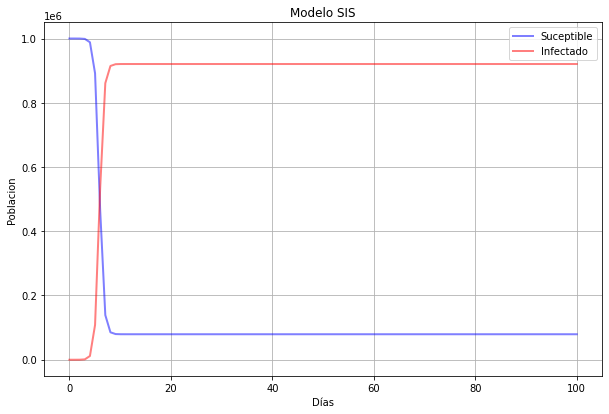

poblacion_total : 1000000
dias : 100
VI_infectados : 1
VI_suceptibles : 999999
promedio_de_contactos : 3
probabilidad_de_transmicion : 0.84
beta : 2.52
gamma : 0.2
tiempo : 100


In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def SuceptiblesIniciales(poblacion_total,VI_infectados):
	return poblacion_total - VI_infectados

def CalcularBeta(promedio_de_contactos,probabilidad_de_transmicion):
	return promedio_de_contactos*probabilidad_de_transmicion

def CalcularGamma(dias_de_recuperacion):
	return 1.0/dias_de_recuperacion

def deriv_suceptible(beta,gamma,suceptible,infectado,poblacion_total):
	return (-beta * suceptible *infectado / poblacion_total) + gamma*infectado

def deriv_infectado(beta,suceptible,infectado,poblacion_total,gamma):
	return (beta * suceptible * infectado / poblacion_total) - gamma*infectado

def deriv_helper(VI,tiempo,poblacion_total,beta,gamma):
	suceptible,infectado= VI

	dSdt = deriv_suceptible(beta,gamma,suceptible, infectado, poblacion_total)
	dIdt = deriv_infectado(beta, suceptible, infectado, poblacion_total, gamma)

	return dSdt, dIdt

def plot_sir(tiempo,suceptible,infectado):
	fig = plt.figure(figsize = (10,6.5),facecolor = 'w')

	ax = fig.add_subplot(111,axisbelow=True)
	ax.plot(tiempo, suceptible, 'b', alpha=0.5,lw=2, label = "Suceptible")
	ax.plot(tiempo, infectado , 'r', alpha=0.5,lw=2, label = "Infectado ")

	ax.set_xlabel("Días")
	ax.set_ylabel("Poblacion")

	ax.set_title("Modelo SIS")
	legend = ax.legend()

	plt.grid()
	plt.show()

if __name__ == "__main__":

	"""Parametros del modelo"""
	#Proponemos una poblacion
	poblacion_total = 1000000

	#numero de dias a considerar
	dias = 100

	#definimos VI_infectados,VI_recuperados
	VI_infectados = 1

	#Definimos beta
	promedio_de_contactos = 3
	probabilidad_de_transmicion = 0.84

	#Definimos gamma
	dias_de_recuperacion = 5

	""" Calculos """
	#valores iniciales para los suceptibles
	VI_suceptibles = SuceptiblesIniciales(poblacion_total, VI_infectados)
	#beta
	beta = CalcularBeta(promedio_de_contactos, probabilidad_de_transmicion)
	#gamma
	gamma = CalcularGamma(dias_de_recuperacion)
	#tiempo
	tiempo = np.linspace(0,dias,dias)
	#condiciones iniciales
	VI = (VI_suceptibles,VI_infectados)
	#integrando el las EDO's
	func_integ = odeint(deriv_helper, VI, tiempo, args = (poblacion_total,beta,gamma))
	suceptible,infectado= func_integ.T
	#dibujamos las graficas
	plot_sir(tiempo,suceptible,infectado)


	""" Salida """
	parametros_dict = {
		"poblacion_total":poblacion_total,
		"dias"           :dias,
		"VI_infectados" :VI_infectados,
		"VI_suceptibles":VI_suceptibles,
		"promedio_de_contactos":promedio_de_contactos,
		"probabilidad_de_transmicion":probabilidad_de_transmicion,
		"beta": beta,
		"gamma":gamma,
		"tiempo":len(tiempo)
	}

	for k,v in parametros_dict.items():
		print("{} : {}".format(k,v))

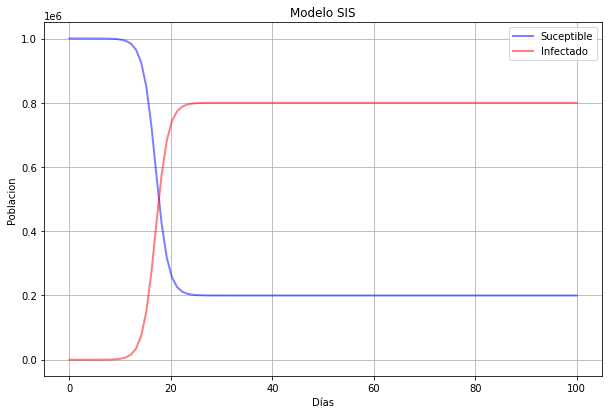

poblacion_total : 1000000
dias : 100
VI_infectados : 1
VI_suceptibles : 999999
promedio_de_contactos : 5
probabilidad_de_transmicion : 0.2
beta : 1.0
gamma : 0.2
tiempo : 100


In [2]:
if __name__ == "__main__":

	"""Parametros del modelo"""
	#Proponemos una poblacion
	poblacion_total = 1000000

	#numero de dias a considerar
	dias = 100

	#definimos VI_infectados,VI_recuperados
	VI_infectados = 1

	#Definimos beta
	promedio_de_contactos = 5
	probabilidad_de_transmicion = 0.20

	#Definimos gamma
	dias_de_recuperacion = 5

	""" Calculos """
	#valores iniciales para los suceptibles
	VI_suceptibles = SuceptiblesIniciales(poblacion_total, VI_infectados)
	#beta
	beta = CalcularBeta(promedio_de_contactos, probabilidad_de_transmicion)
	#gamma
	gamma = CalcularGamma(dias_de_recuperacion)
	#tiempo
	tiempo = np.linspace(0,dias,dias)
	#condiciones iniciales
	VI = (VI_suceptibles,VI_infectados)
	#integrando el las EDO's
	func_integ = odeint(deriv_helper, VI, tiempo, args = (poblacion_total,beta,gamma))
	suceptible,infectado= func_integ.T
	#dibujamos las graficas
	plot_sir(tiempo,suceptible,infectado)


	""" Salida """
	parametros_dict = {
		"poblacion_total":poblacion_total,
		"dias"           :dias,
		"VI_infectados" :VI_infectados,
		"VI_suceptibles":VI_suceptibles,
		"promedio_de_contactos":promedio_de_contactos,
		"probabilidad_de_transmicion":probabilidad_de_transmicion,
		"beta": beta,
		"gamma":gamma,
		"tiempo":len(tiempo)
	}

	for k,v in parametros_dict.items():
		print("{} : {}".format(k,v))